In [1]:
%matplotlib inline

import math
import numpy as np
import matplotlib.pyplot as plt

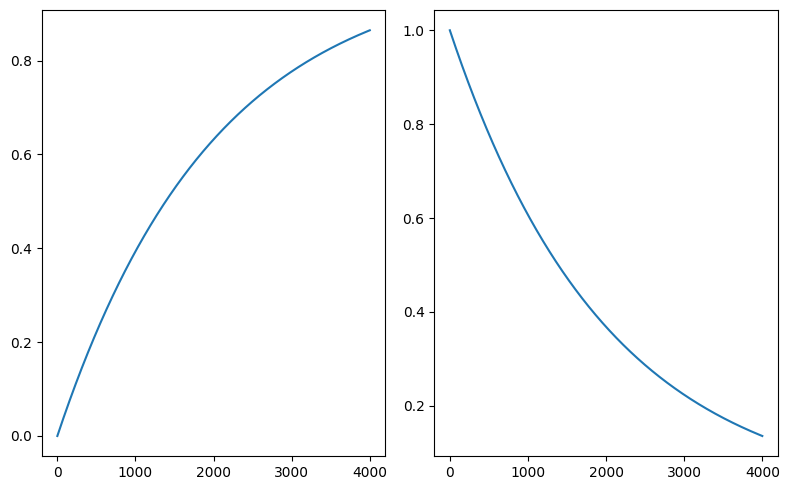

In [2]:
decay=0.9999
tau=2000

decay_func=lambda x: decay*(1-math.exp(-x/tau)) # decay exponential ramp (to help early epochs)
updates=np.arange(0,4000)
d=[decay_func(u) for u in updates]
_, ax=plt.subplots(1,2,figsize=(8,5),tight_layout=True)
ax[0].plot(updates, d) # weight of EMA
ax[1].plot(updates,[1-i for i in d]) # weight of training model

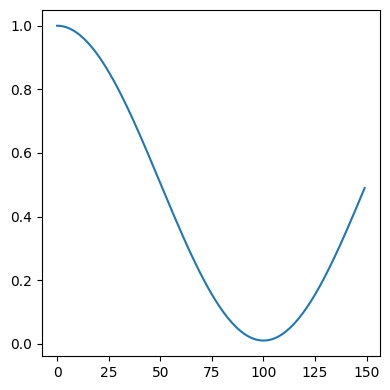

In [7]:
def one_cycle(y1=0., y2=1., steps=100):
    """
    Return a lambda function for sinusoidal ramp from y1 to y2 https://arxiv.org/pdf/1812.01187.pdf.
    Args:
        y1 (float, optional): Initial value
        y2 (float, optional): Final value
        steps (int, optional): Number of steps
    Returns:
        (function): Lambda function for computing sinusoidal ramp
    """
    return lambda x: max(0, (1-math.cos(x*math.pi/steps))/2)*(y2-y1)+y1
    
func=one_cycle(y1=1, y2=0.01, steps=100)

x=np.arange(0,150)
y=[func(i) for i in x]
_, ax=plt.subplots(1,1,figsize=(4,4),tight_layout=True)
ax.plot(x, y) 

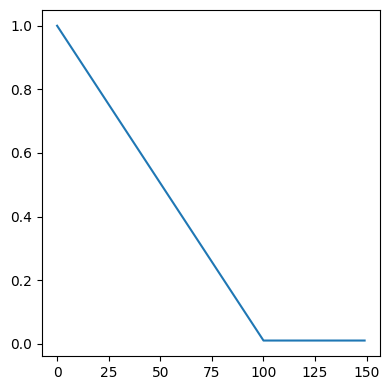

In [8]:
func=lambda x: max(1-x/100, 0)*(1.0-0.01)+0.01 
x=np.arange(0,150)
y=[func(i) for i in x]
_, ax=plt.subplots(1,1,figsize=(4,4),tight_layout=True)
ax.plot(x, y) 